In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Country-data (1).csv")

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.shape

(167, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cat_cols=['country']
#rest all cols are numerical
num_cols = [
'child_mort',
'exports',
'health',
'imports',
'income',
'inflation',
'life_expec',
'total_fer',
'gdpp'
]

In [ ]:
df['country'].nunique()

167

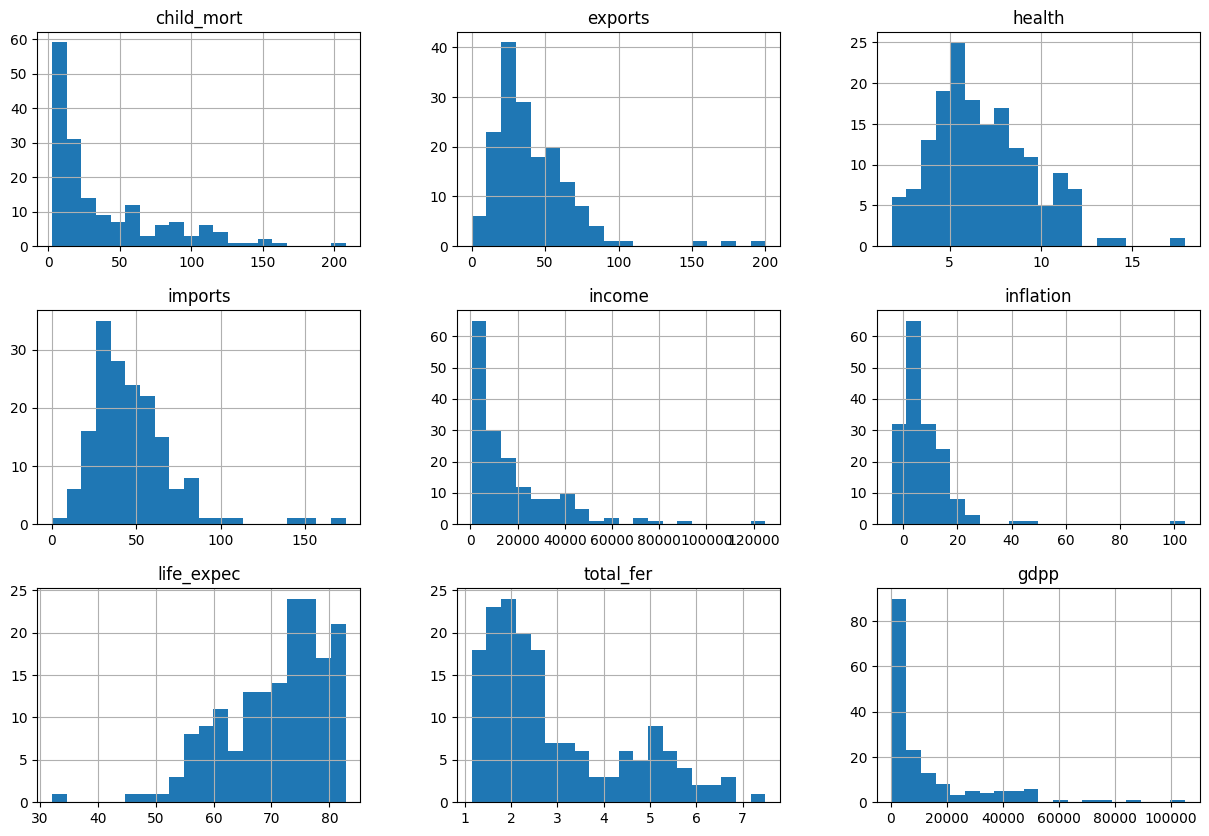

In [ ]:

df[num_cols].hist(
    figsize=(15,10),
    bins=20
)


plt.show()




<Axes: ylabel='Density'>

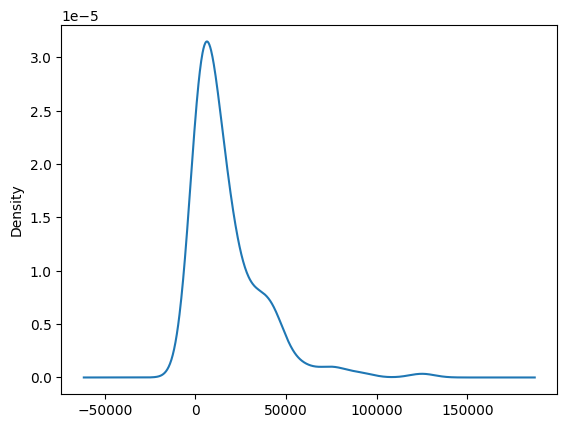

In [ ]:
df['income'].plot(kind='kde')

<Axes: ylabel='Density'>

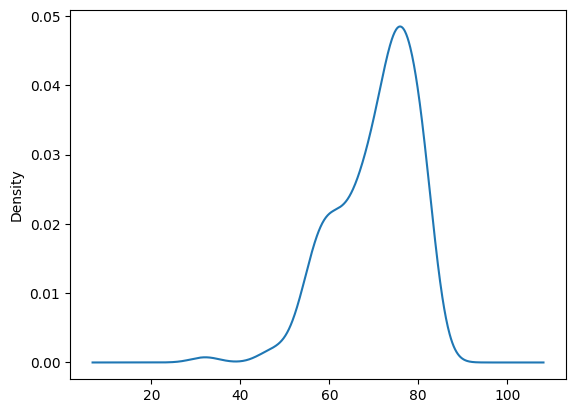

In [ ]:
df['life_expec'].plot(kind='kde')

<Axes: ylabel='Density'>

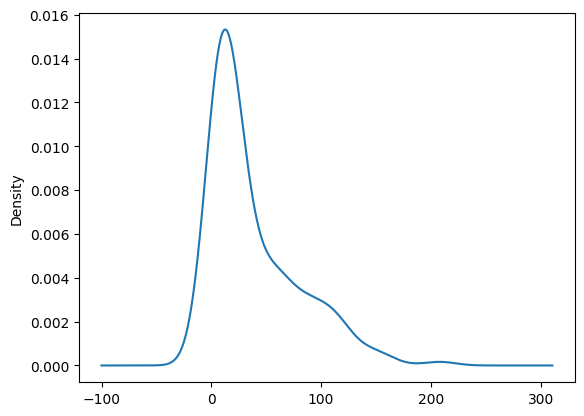

In [ ]:
df['child_mort'].plot(kind='kde')

In [ ]:
df.skew(numeric_only=True)

,0
child_mort,1.450774
exports,2.445824
health,0.705746
imports,1.905276
income,2.231480
inflation,5.154049
life_expec,-0.970996
total_fer,0.967092
gdpp,2.218051


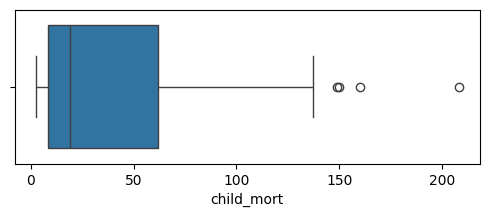

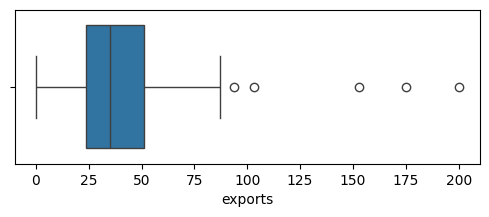

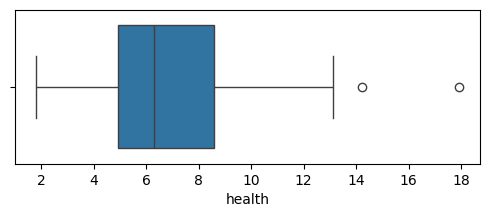

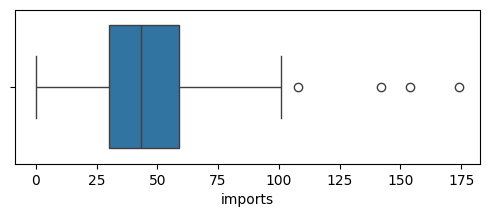

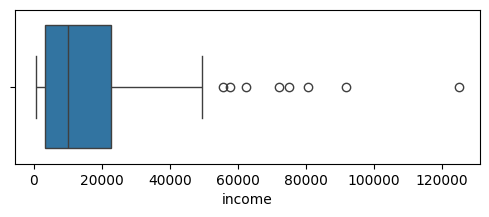

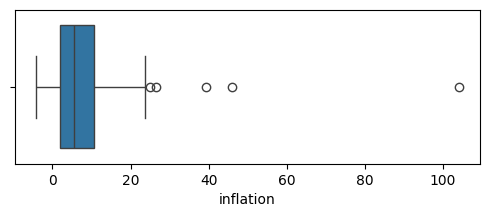

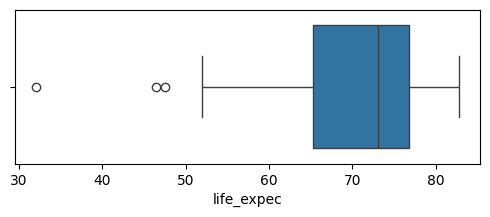

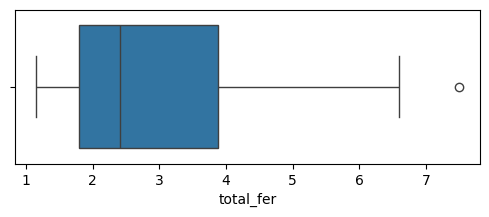

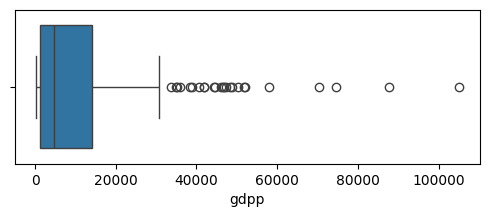

In [ ]:
for col in df.columns[1:]:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.show()

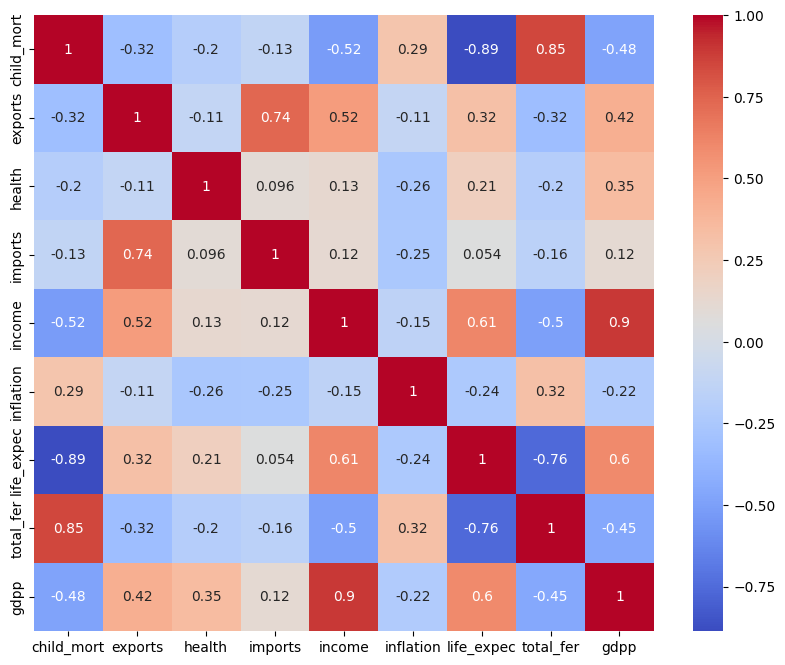

In [ ]:
corr = df.drop('country',axis=1).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i)
  km.fit(X_scaled)
  wcss.append(km.inertia_)

In [ ]:
wcss

[1503.0000000000002,
 1050.2145582853307,
 831.424435208687,
 766.1549883816687,
 637.0860066063714,
 613.1161597967584,
 624.2456924735818,
 484.4077362351787,
 432.42666555099754,
 406.88917475353486]

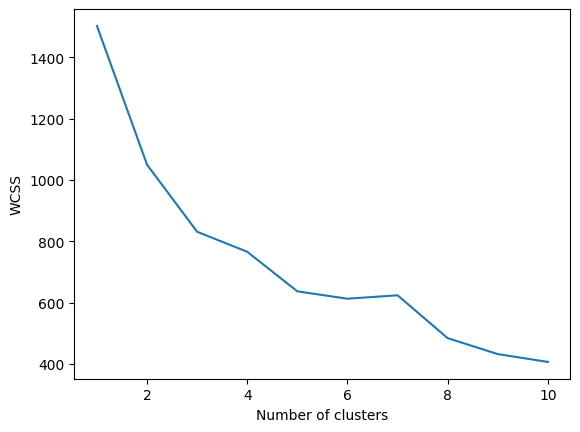

In [ ]:
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
X=df.iloc[:,:].values
km=KMeans(n_clusters=3, random_state=42)
y=km.fit_predict(X_scaled)

In [ ]:
X_scaled[y==0]

array([[-5.38948897e-01, -4.79658426e-01, -9.70161825e-02,
         7.08366942e-02, -3.75368896e-01, -3.12347469e-01,
         6.47866431e-01, -8.59972814e-01, -4.85623236e-01],
       [-2.72832734e-01, -9.91216387e-02, -9.66073021e-01,
        -6.41762328e-01, -2.20844469e-01,  7.89274285e-01,
         6.70423231e-01, -3.84043958e-02, -4.65375609e-01],
       [-6.95634115e-01,  1.60667899e-01, -2.86894147e-01,
         4.97567504e-01,  1.01731774e-01, -6.01748532e-01,
         7.04258432e-01, -5.41946330e-01, -4.18171341e-02],
       [-5.91177303e-01, -8.12628115e-01,  4.68966212e-01,
        -1.27978703e+00,  8.09204035e-02,  1.24472514e+00,
         5.91474429e-01, -3.82933087e-01, -1.45791437e-01],
       [-5.01642893e-01, -7.43106971e-01, -8.82088536e-01,
        -6.58828857e-02, -5.43420713e-01, -1.12271817e-03,
         3.09514422e-01, -8.33470607e-01, -5.33232522e-01],
       [ 2.31282334e-02,  4.82660565e-01, -3.41666637e-01,
        -1.08506521e+00, -5.95563477e-02,  5.710374

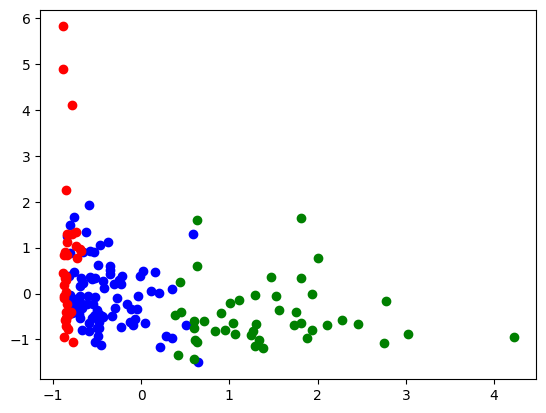

In [ ]:
plt.scatter(X_scaled[y==0,0],X_scaled[y==0,1],color='blue')
plt.scatter(X_scaled[y==1,0],X_scaled[y==1,1],color='red')
plt.scatter(X_scaled[y==2,0],X_scaled[y==2,1],color='green')

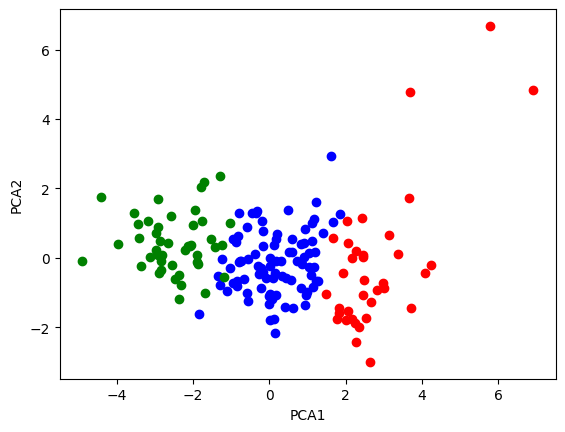

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[y==0,0], X_pca[y==0,1], c='blue')
plt.scatter(X_pca[y==1,0], X_pca[y==1,1], c='red')
plt.scatter(X_pca[y==2,0], X_pca[y==2,1], c='green')

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled,y)

print(score)

0.285600988953231
